In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
anomaly_periods = pd.read_csv(
    "detected_abnormal_periods.csv",
    parse_dates=["start_time", "end_time"]
)
data = pd.read_csv(
    "feature_engineered_data.csv",
    parse_dates=["time"]
)
print("Anomaly periods:", len(anomaly_periods))
print("Sensor data:", len(data))

Anomaly periods: 252
Sensor data: 377719


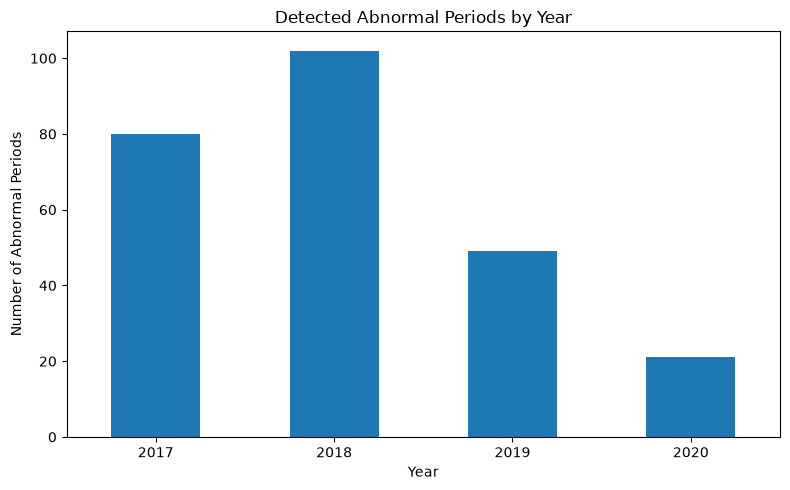

In [2]:
year_counts = (
    anomaly_periods
    .assign(year=anomaly_periods["start_time"].dt.year)
    .groupby("year")
    .size()
)
plt.figure(figsize=(8, 5))
year_counts.plot(kind="bar")
plt.title("Detected Abnormal Periods by Year")
plt.xlabel("Year")
plt.ylabel("Number of Abnormal Periods")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

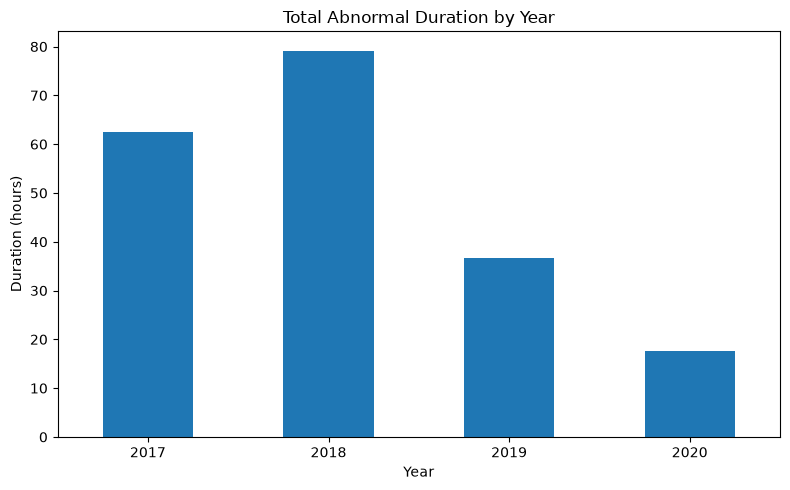

In [3]:
anomaly_periods["duration_hours"] = (
    pd.to_timedelta(anomaly_periods["duration"]).dt.total_seconds() / 3600
)

year_duration = (
    anomaly_periods
    .assign(year=anomaly_periods["start_time"].dt.year)
    .groupby("year")["duration_hours"]
    .sum()
)

plt.figure(figsize=(8, 5))
year_duration.plot(kind="bar")

plt.title("Total Abnormal Duration by Year")
plt.xlabel("Year")
plt.ylabel("Duration (hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

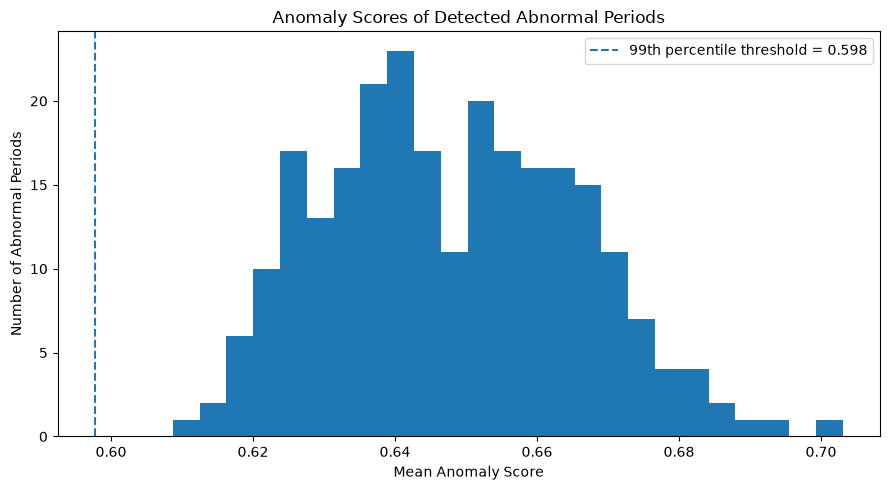

In [9]:
# Distribution of mean anomaly scores for detected abnormal periods

plt.figure(figsize=(9, 5))

plt.hist(
    anomaly_periods["mean_score"],
    bins=25
)

threshold_99 = 0.597745

plt.axvline(
    threshold_99,
    linestyle="--",
    label=f"99th percentile threshold = {threshold_99:.3f}"
)

plt.title("Anomaly Scores of Detected Abnormal Periods")
plt.xlabel("Mean Anomaly Score")
plt.ylabel("Number of Abnormal Periods")
plt.legend()

plt.tight_layout()
plt.show()

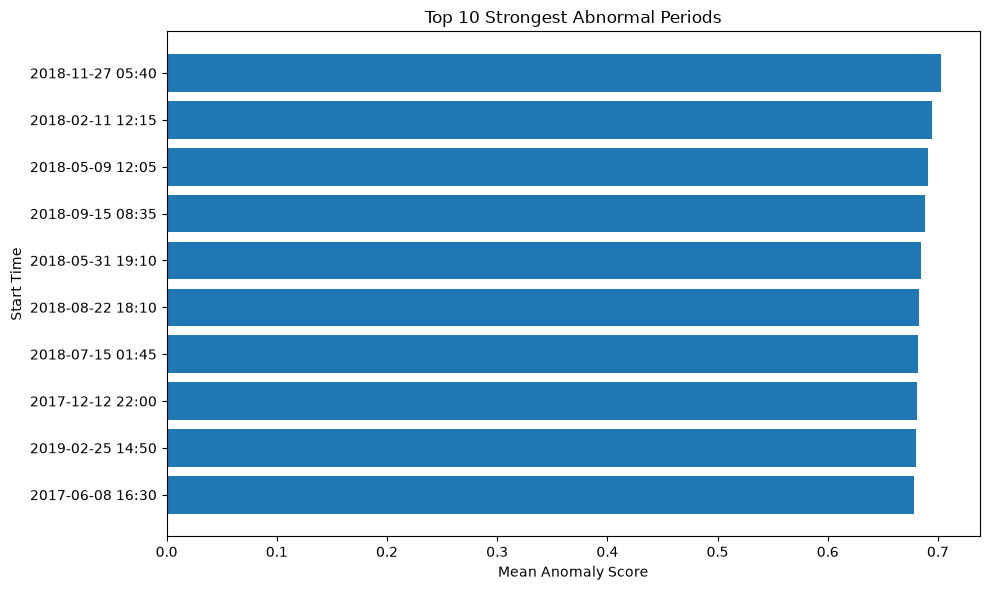

In [ ]:
top_10 = (
    anomaly_periods
    .sort_values("mean_score", ascending=False)
    .head(10)
    .copy()
)
top_10["label"] = (
    top_10["start_time"].dt.strftime("%Y-%m-%d %H:%M")
)
plt.figure(figsize=(10, 6))
plt.barh(
    top_10["label"].iloc[::-1],
    top_10["mean_score"].iloc[::-1]
)
plt.title("Top 10 Strongest Abnormal Periods")
plt.xlabel("Mean Anomaly Score")
plt.ylabel("Start Time")

plt.tight_layout()
plt.show()

In [6]:
top_period = anomaly_periods.sort_values(
    "mean_score",
    ascending=False
).iloc[0]

start = top_period["start_time"]
end = top_period["end_time"]

# Show 1 hour before and 1 hour after
plot_start = start - pd.Timedelta(hours=1)
plot_end = end + pd.Timedelta(hours=1)

period_data = data[
    (data["time"] >= plot_start) &
    (data["time"] <= plot_end)
].copy()

print("Period:", start, "to", end)

Period: 2018-11-27 05:40:00 to 2018-11-27 06:30:00


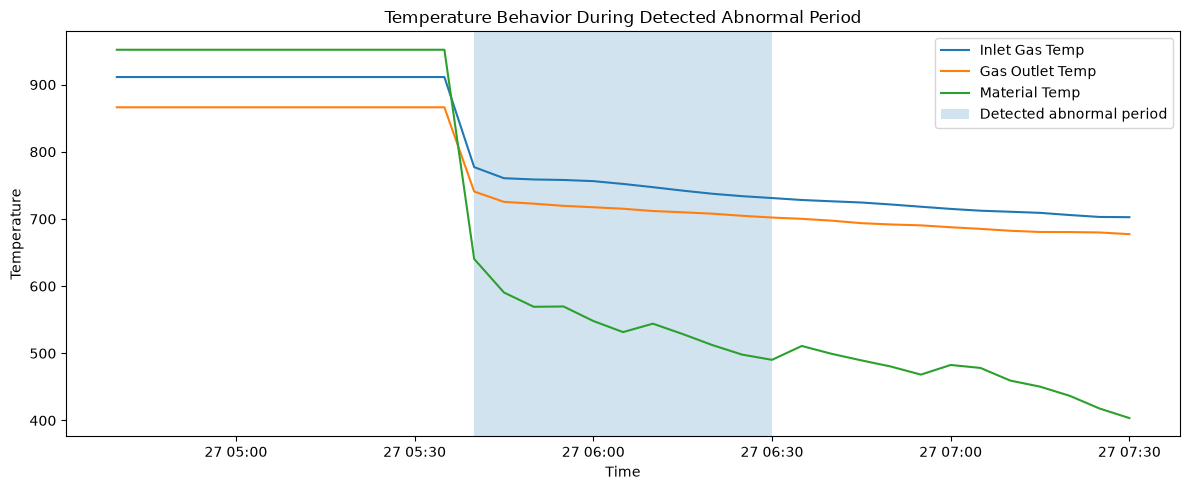

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    period_data["time"],
    period_data["Cyclone_Inlet_Gas_Temp"],
    label="Inlet Gas Temp"
)
plt.plot(
    period_data["time"],
    period_data["Cyclone_Gas_Outlet_Temp"],
    label="Gas Outlet Temp"
)
plt.plot(
    period_data["time"],
    period_data["Cyclone_Material_Temp"],
    label="Material Temp"
)
plt.axvspan(
    start,
    end,
    alpha=0.2,
    label="Detected abnormal period"
)
plt.title("Temperature Behavior During Detected Abnormal Period")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

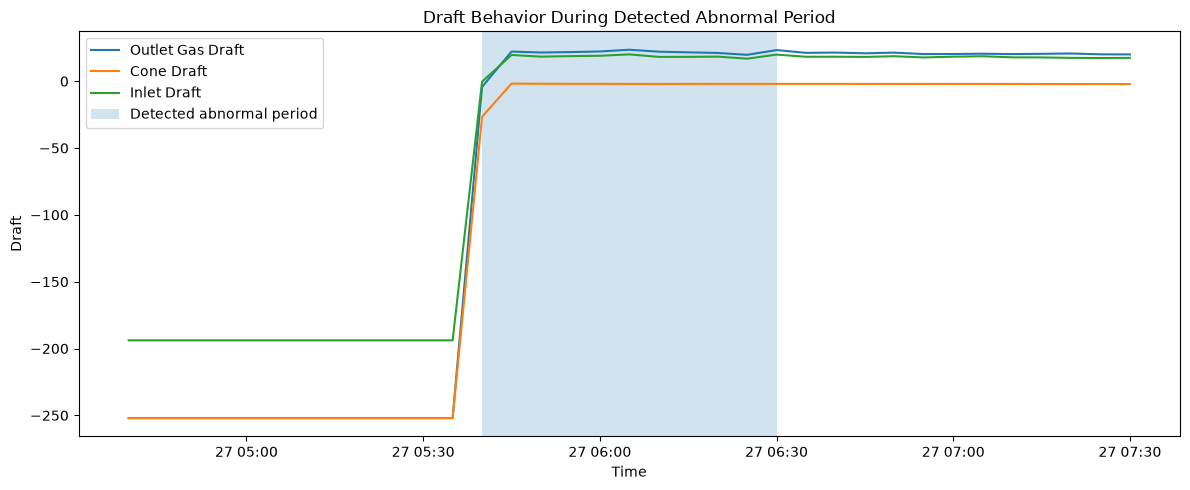

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    period_data["time"],
    period_data["Cyclone_Outlet_Gas_draft"],
    label="Outlet Gas Draft"
)
plt.plot(
    period_data["time"],
    period_data["Cyclone_cone_draft"],
    label="Cone Draft"
)
plt.plot(
    period_data["time"],
    period_data["Cyclone_Inlet_Draft"],
    label="Inlet Draft"
)
plt.axvspan(
    start,
    end,
    alpha=0.2,
    label="Detected abnormal period"
)
plt.title("Draft Behavior During Detected Abnormal Period")
plt.xlabel("Time")
plt.ylabel("Draft")
plt.legend()
plt.tight_layout()
plt.show()

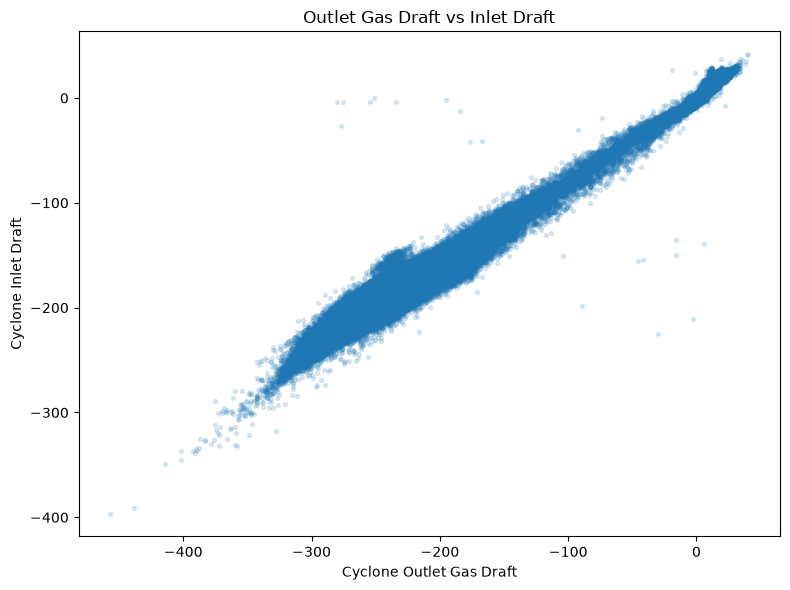

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data["Cyclone_Outlet_Gas_draft"],
    data["Cyclone_Inlet_Draft"],
    alpha=0.15,
    s=8
)

plt.title("Outlet Gas Draft vs Inlet Draft")
plt.xlabel("Cyclone Outlet Gas Draft")
plt.ylabel("Cyclone Inlet Draft")

plt.tight_layout()
plt.show()


In [12]:
scores = pd.read_csv(
    "anomaly_scores.csv",
    parse_dates=["time"]
)

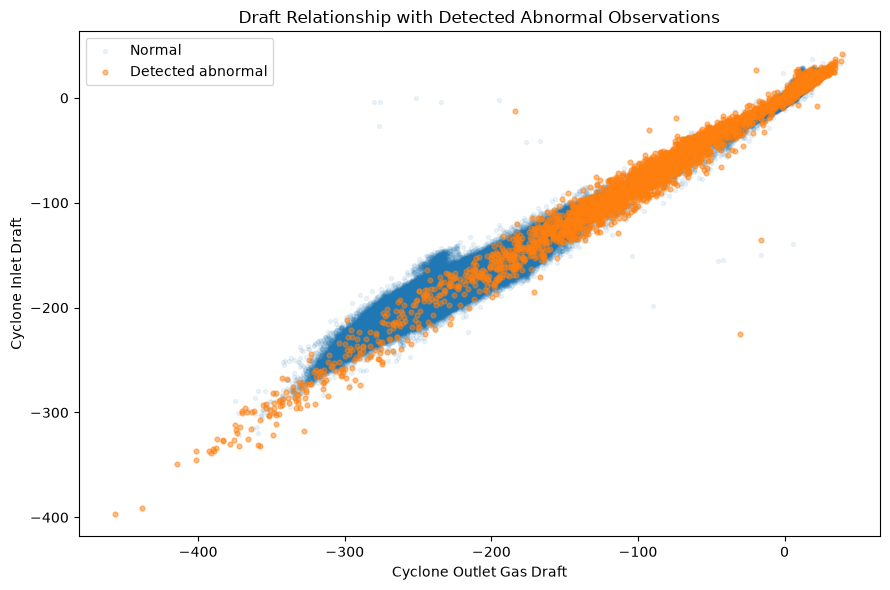

In [13]:
plot_data = data.merge(
    scores[["time", "anomaly_score", "anomaly_99"]],
    on="time",
    how="inner"
)

normal = plot_data[~plot_data["anomaly_99"]]
abnormal = plot_data[plot_data["anomaly_99"]]

plt.figure(figsize=(9, 6))

plt.scatter(
    normal["Cyclone_Outlet_Gas_draft"],
    normal["Cyclone_Inlet_Draft"],
    alpha=0.08,
    s=8,
    label="Normal"
)

plt.scatter(
    abnormal["Cyclone_Outlet_Gas_draft"],
    abnormal["Cyclone_Inlet_Draft"],
    alpha=0.5,
    s=12,
    label="Detected abnormal"
)

plt.title("Draft Relationship with Detected Abnormal Observations")
plt.xlabel("Cyclone Outlet Gas Draft")
plt.ylabel("Cyclone Inlet Draft")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
[c for c in data.columns if "rolling" in c.lower() or "roll" in c.lower()]

['Cyclone_Inlet_Gas_Temp_rolling_mean_60min',
 'Cyclone_Inlet_Gas_Temp_rolling_std_60min',
 'Cyclone_Gas_Outlet_Temp_rolling_mean_60min',
 'Cyclone_Gas_Outlet_Temp_rolling_std_60min',
 'Cyclone_Outlet_Gas_draft_rolling_mean_60min',
 'Cyclone_Outlet_Gas_draft_rolling_std_60min',
 'Cyclone_cone_draft_rolling_mean_60min',
 'Cyclone_cone_draft_rolling_std_60min',
 'Cyclone_Inlet_Draft_rolling_mean_60min',
 'Cyclone_Inlet_Draft_rolling_std_60min',
 'Cyclone_Material_Temp_rolling_mean_60min',
 'Cyclone_Material_Temp_rolling_std_60min']

In [17]:
[c for c in data.columns if "Cyclone_Inlet_Gas_Temp" in c]

['Cyclone_Inlet_Gas_Temp',
 'Cyclone_Inlet_Gas_Temp_change_5min',
 'Cyclone_Inlet_Gas_Temp_change_30min',
 'Cyclone_Inlet_Gas_Temp_change_60min',
 'Cyclone_Inlet_Gas_Temp_rolling_mean_60min',
 'Cyclone_Inlet_Gas_Temp_rolling_std_60min']

In [18]:
[c for c in data.columns if "Cyclone_Inlet_Gas_Temp" in c]

['Cyclone_Inlet_Gas_Temp',
 'Cyclone_Inlet_Gas_Temp_change_5min',
 'Cyclone_Inlet_Gas_Temp_change_30min',
 'Cyclone_Inlet_Gas_Temp_change_60min',
 'Cyclone_Inlet_Gas_Temp_rolling_mean_60min',
 'Cyclone_Inlet_Gas_Temp_rolling_std_60min']

Rolling statistics visualization


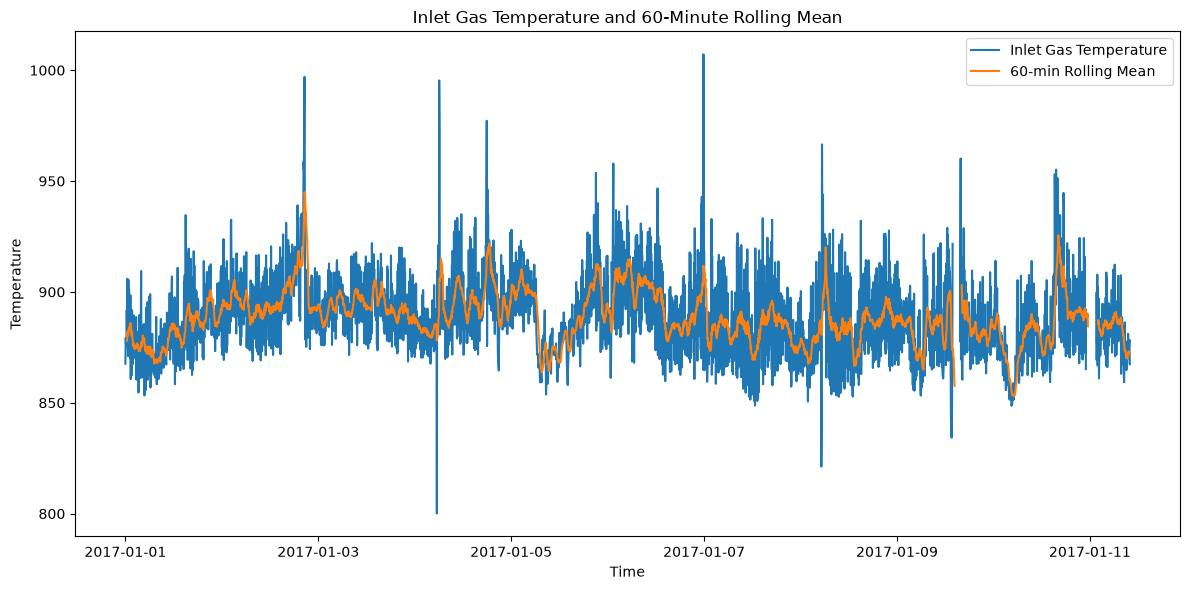

In [19]:
plt.figure(figsize=(12, 6))

sample = data.iloc[:3000].copy()

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp"],
    label="Inlet Gas Temperature"
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_rolling_mean_60min"],
    label="60-min Rolling Mean"
)

plt.title("Inlet Gas Temperature and 60-Minute Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

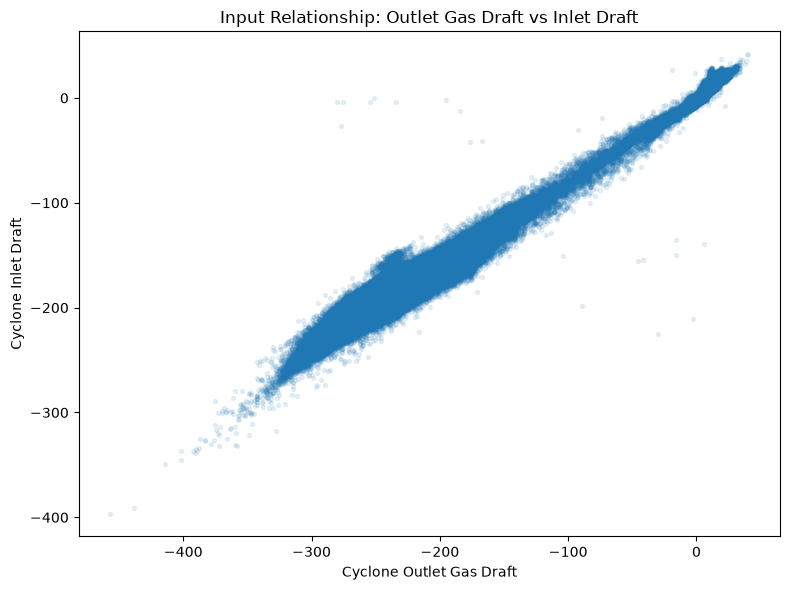

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data["Cyclone_Outlet_Gas_draft"],
    data["Cyclone_Inlet_Draft"],
    alpha=0.1,
    s=8
)

plt.title("Input Relationship: Outlet Gas Draft vs Inlet Draft")
plt.xlabel("Cyclone Outlet Gas Draft")
plt.ylabel("Cyclone Inlet Draft")

plt.tight_layout()
plt.show()

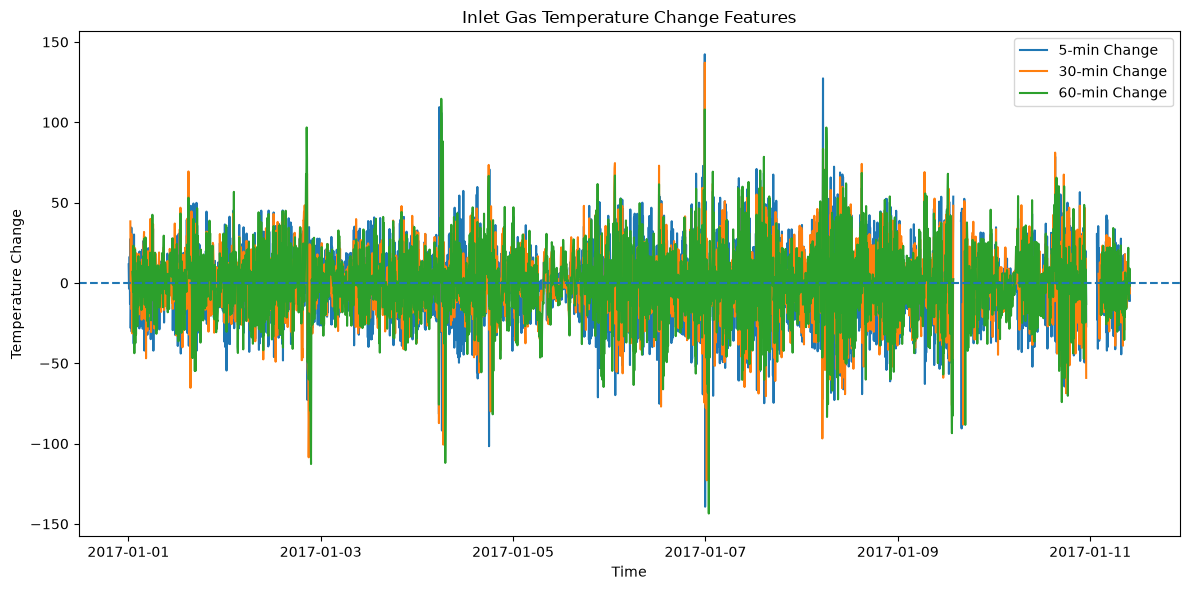

In [20]:
plt.figure(figsize=(12, 6))

sample = data.iloc[:3000].copy()

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_5min"],
    label="5-min Change"
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_30min"],
    label="30-min Change"
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_60min"],
    label="60-min Change"
)

plt.axhline(0, linestyle="--")

plt.title("Inlet Gas Temperature Change Features")
plt.xlabel("Time")
plt.ylabel("Temperature Change")
plt.legend()

plt.tight_layout()
plt.show()

Overall data plot

C:\Users\VijaySegunasi\AppData\Local\Temp\ipykernel_2884\3886771302.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


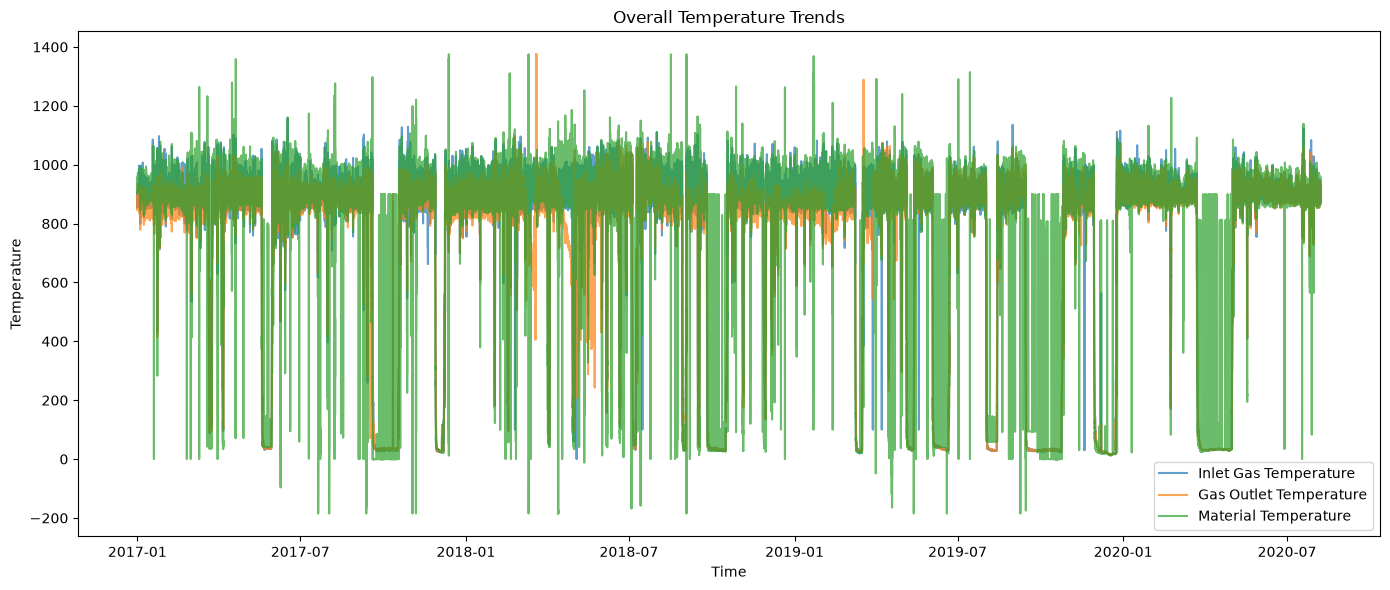

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    data["time"],
    data["Cyclone_Inlet_Gas_Temp"],
    label="Inlet Gas Temperature",
    alpha=0.7
)

plt.plot(
    data["time"],
    data["Cyclone_Gas_Outlet_Temp"],
    label="Gas Outlet Temperature",
    alpha=0.7
)

plt.plot(
    data["time"],
    data["Cyclone_Material_Temp"],
    label="Material Temperature",
    alpha=0.7
)

plt.title("Overall Temperature Trends")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

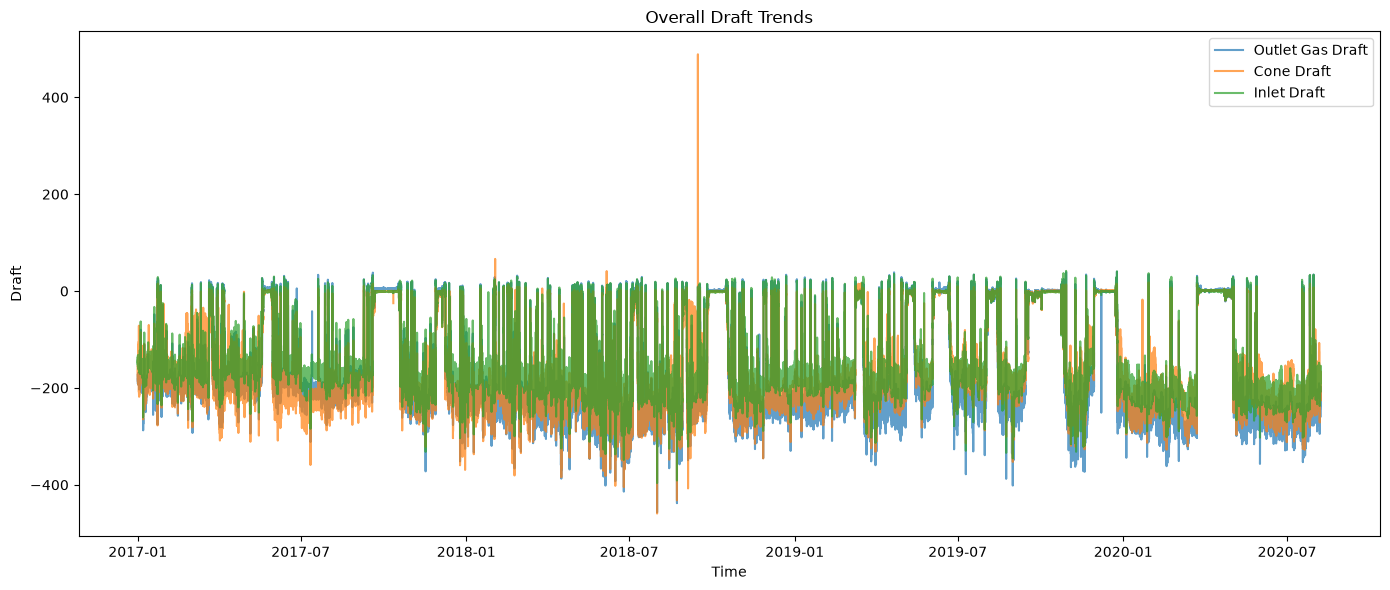

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    data["time"],
    data["Cyclone_Outlet_Gas_draft"],
    label="Outlet Gas Draft",
    alpha=0.7
)

plt.plot(
    data["time"],
    data["Cyclone_cone_draft"],
    label="Cone Draft",
    alpha=0.7
)

plt.plot(
    data["time"],
    data["Cyclone_Inlet_Draft"],
    label="Inlet Draft",
    alpha=0.7
)

plt.title("Overall Draft Trends")
plt.xlabel("Time")
plt.ylabel("Draft")
plt.legend()

plt.tight_layout()
plt.show()

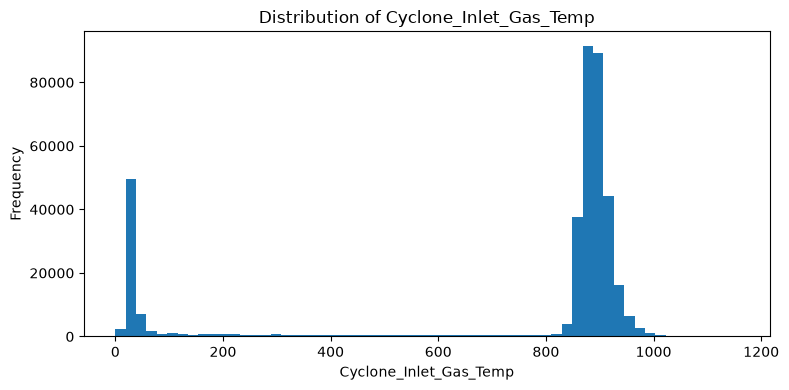

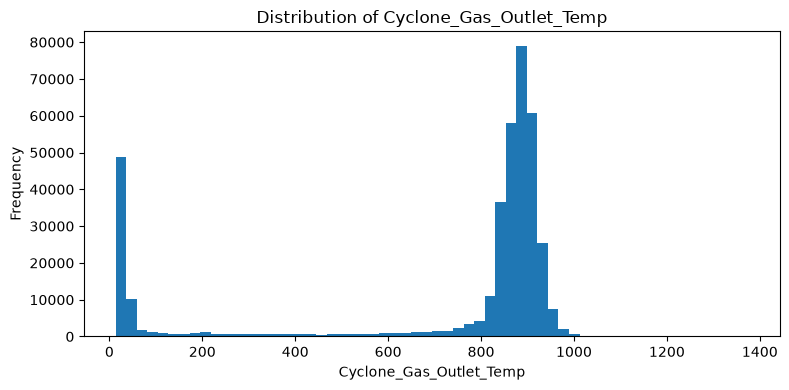

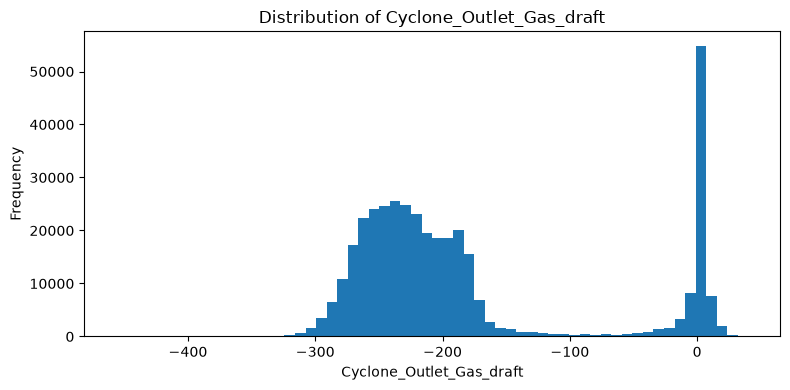

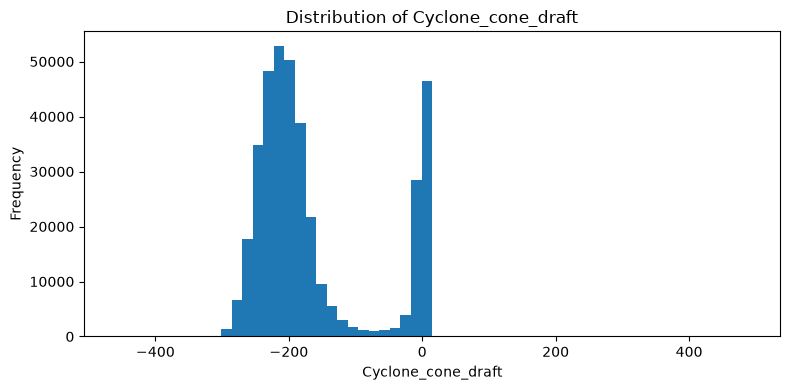

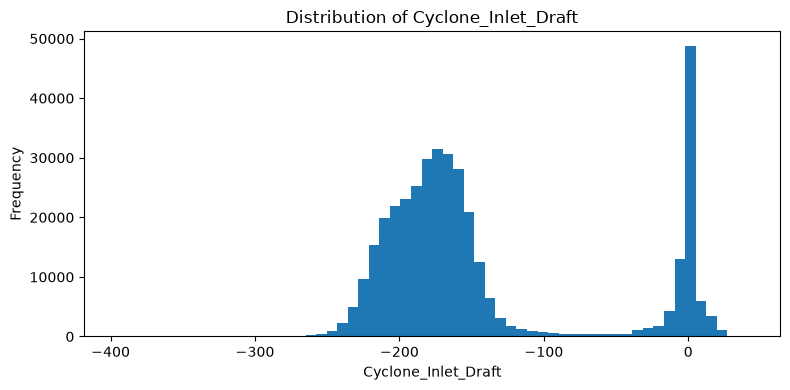

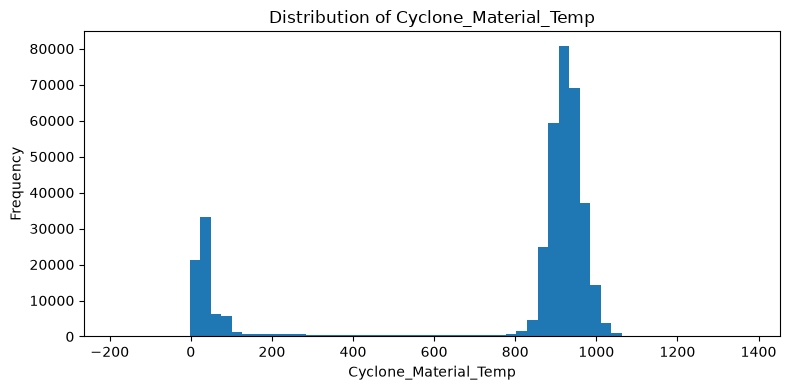

In [23]:
sensor_cols = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Gas_Outlet_Temp",
    "Cyclone_Outlet_Gas_draft",
    "Cyclone_cone_draft",
    "Cyclone_Inlet_Draft",
    "Cyclone_Material_Temp"
]

for col in sensor_cols:
    plt.figure(figsize=(8, 4))

    plt.hist(
        data[col].dropna(),
        bins=60
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

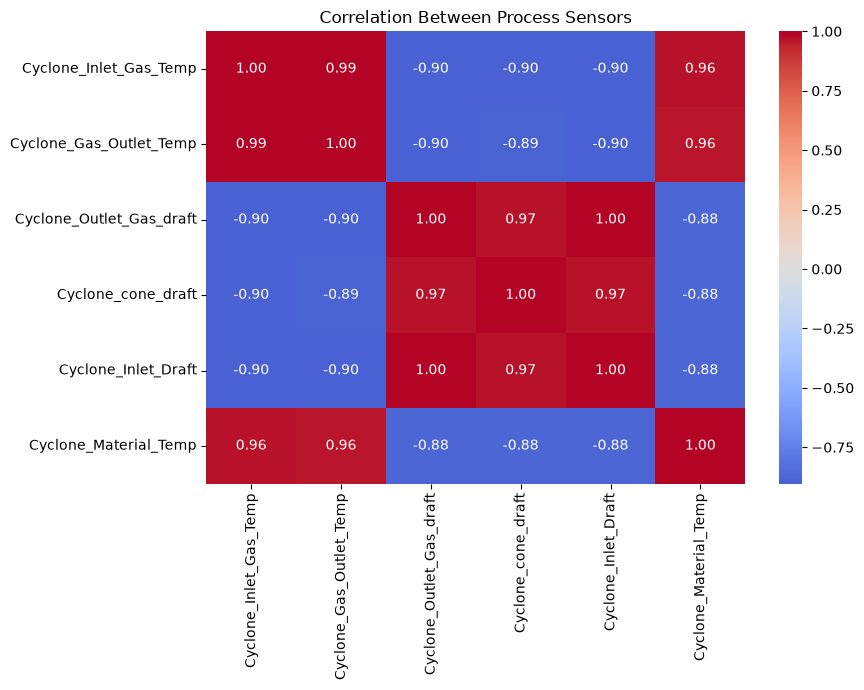

In [24]:
import seaborn as sns

correlation = data[sensor_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Process Sensors")

plt.tight_layout()
plt.show()

feature-engineering visualizations

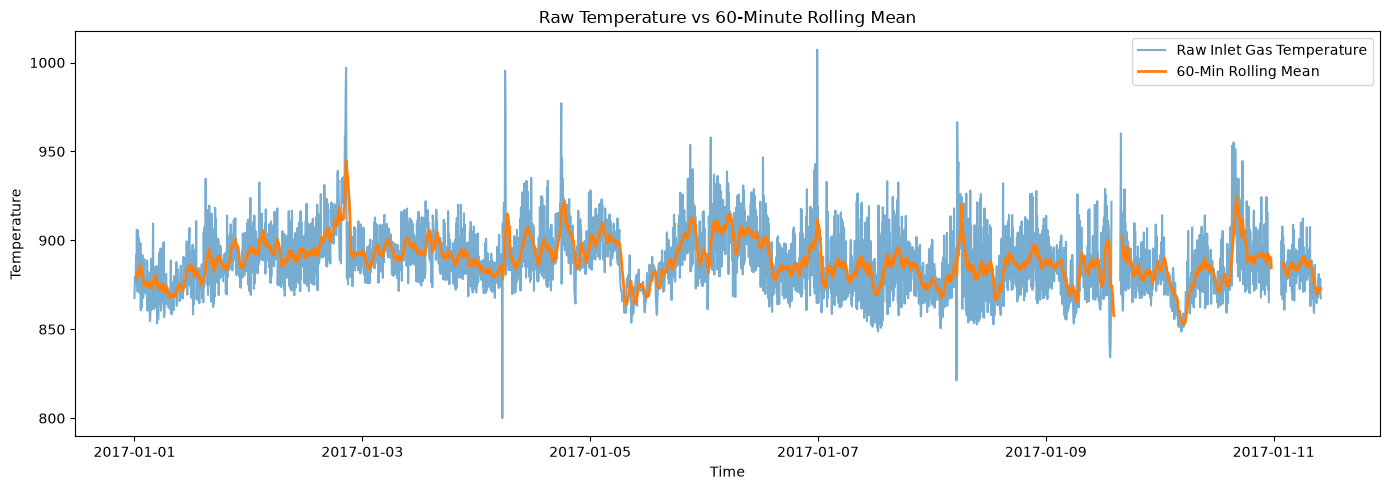

In [27]:
plt.figure(figsize=(14, 5))

sample = data.iloc[:3000].copy()

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp"],
    label="Raw Inlet Gas Temperature",
    alpha=0.6
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_rolling_mean_60min"],
    label="60-Min Rolling Mean",
    linewidth=2
)

plt.title("Raw Temperature vs 60-Minute Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

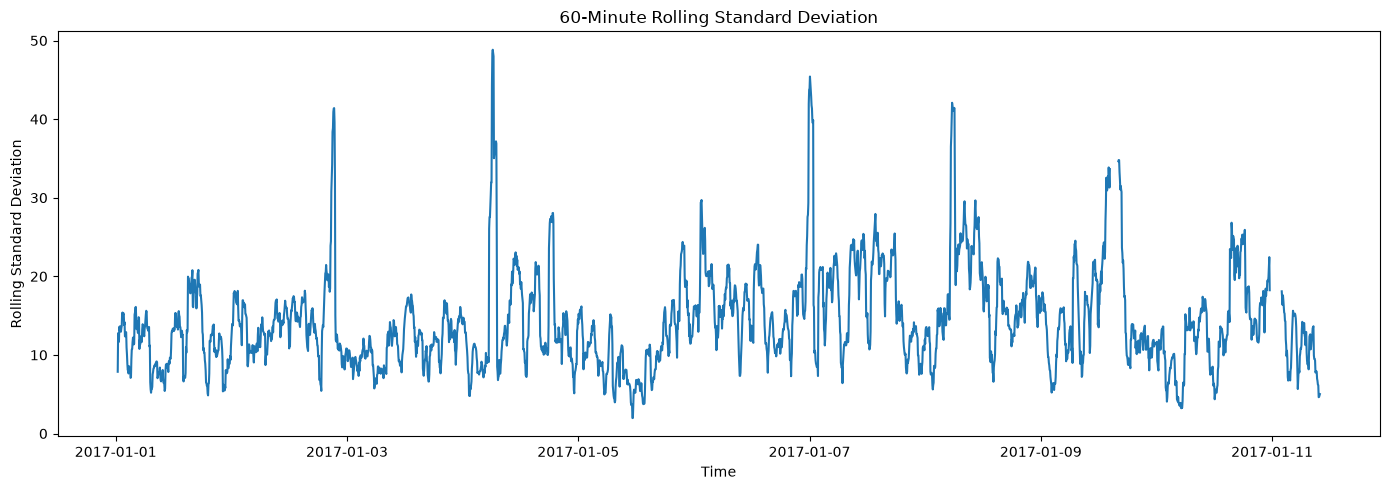

In [28]:
plt.figure(figsize=(14, 5))

sample = data.iloc[:3000].copy()

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_rolling_std_60min"]
)

plt.title("60-Minute Rolling Standard Deviation")
plt.xlabel("Time")
plt.ylabel("Rolling Standard Deviation")

plt.tight_layout()
plt.show()

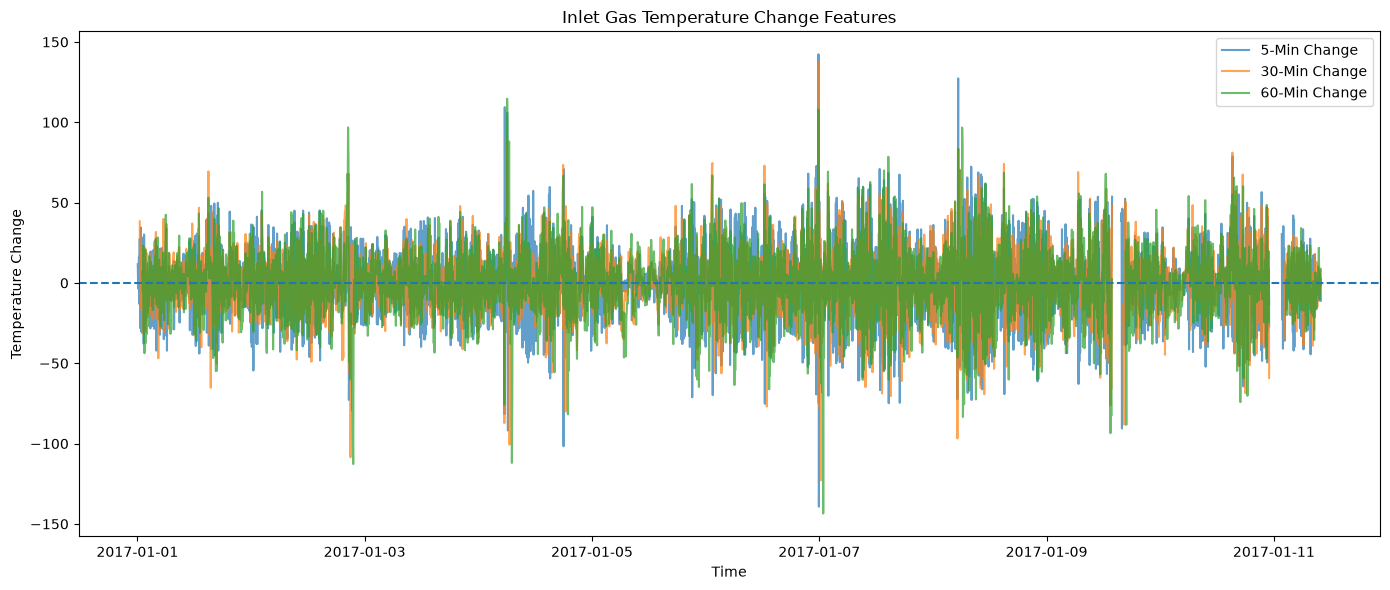

In [29]:
plt.figure(figsize=(14, 6))

sample = data.iloc[:3000].copy()

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_5min"],
    label="5-Min Change",
    alpha=0.7
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_30min"],
    label="30-Min Change",
    alpha=0.7
)

plt.plot(
    sample["time"],
    sample["Cyclone_Inlet_Gas_Temp_change_60min"],
    label="60-Min Change",
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.title("Inlet Gas Temperature Change Features")
plt.xlabel("Time")
plt.ylabel("Temperature Change")
plt.legend()

plt.tight_layout()
plt.show()